Encontradas 3 intervalos para este bloco.


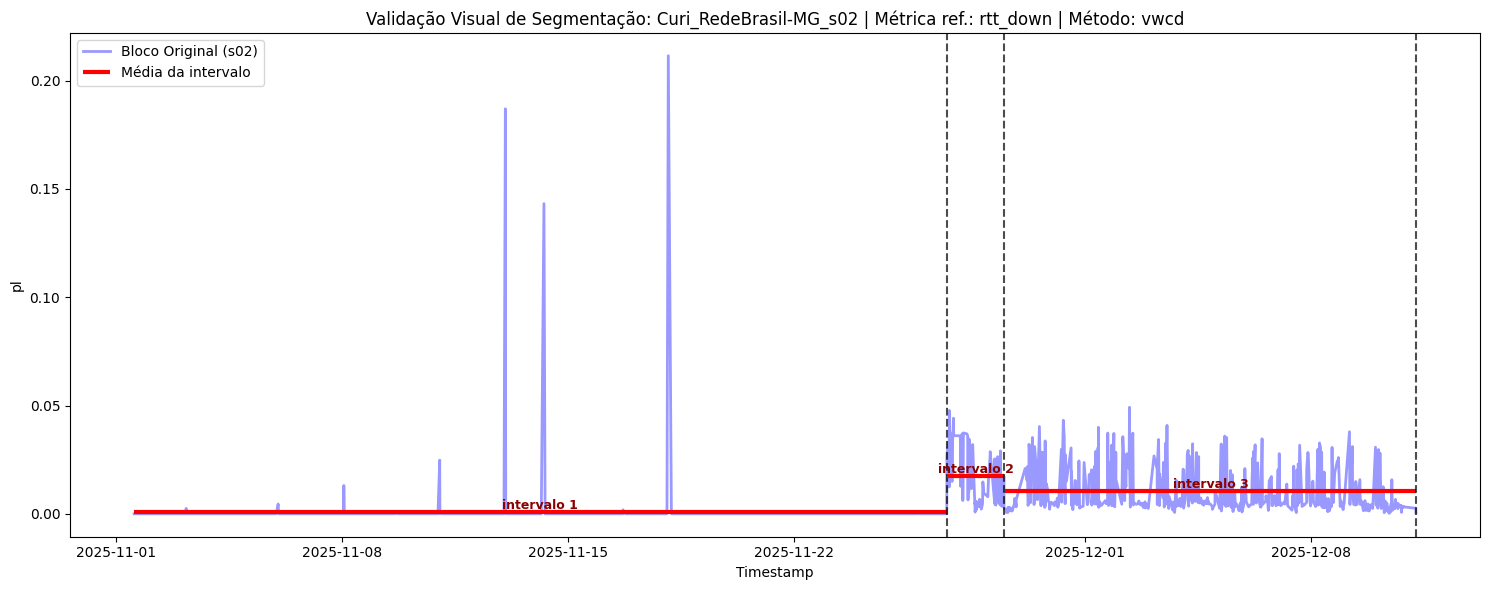


--- PROVA REAL: intervalo 1 ---
Período: 2025-11-01 13:21:10 até 2025-11-26 17:07:34
Nº de pontos  -> Recalculado: 980 | No CSV: 980 -> Bateu? True
Média         -> Recalculado: 0.000628 | No CSV: 0.000628 -> Bateu? True
Desvio Padrão -> Recalculado: 0.010161 | No CSV: 0.010161 -> Bateu? True

--- PROVA REAL: intervalo 2 ---
Período: 2025-11-26 17:16:15 até 2025-11-28 11:37:45
Nº de pontos  -> Recalculado: 71 | No CSV: 71 -> Bateu? True
Média         -> Recalculado: 0.017363 | No CSV: 0.017363 -> Bateu? True
Desvio Padrão -> Recalculado: 0.014073 | No CSV: 0.014073 -> Bateu? True

--- PROVA REAL: intervalo 3 ---
Período: 2025-11-28 12:45:05 até 2025-12-11 05:42:53
Nº de pontos  -> Recalculado: 492 | No CSV: 492 -> Bateu? True
Média         -> Recalculado: 0.010379 | No CSV: 0.010379 -> Bateu? True
Desvio Padrão -> Recalculado: 0.010187 | No CSV: 0.010187 -> Bateu? True


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ==========================================
# 1. ESCOLHA DOS PARÂMETROS PARA VALIDAÇÃO
# ==========================================
scenario = "NDT"
method = "vwcd"
threshold = 0.95 # Usado se for vwcd
ref_metric = "rtt_down" # Métrica usada para guiar a segmentação
metric_to_validate = "pl" # Qual métrica de valor queremos plotar/verificar?

# Escolha do arquivo específico
client = "Curi"
server = "RedeBrasil-MG"
bloco_coleta = "s02" # O seu seguimento original (arquivo completo)

# Escolha de uma intervalo específica gerada pelo algoritmo para a prova real
intervalo_algoritmo = 2

# ==========================================
# 2. CARREGANDO OS DADOS
# ==========================================
file_name = f"{client}_{server}_{bloco_coleta}.csv"
raw_path = os.path.join("results", scenario, "full", method, file_name)

if method.startswith("vwcd"):
    summary_path = os.path.join("segments", scenario, f"{method}_{ref_metric}_{threshold}.csv")
else:
    summary_path = os.path.join("segments", scenario, f"{method}_{ref_metric}.csv")

# Lendo o arquivo original (raw)
df_raw = pd.read_csv(raw_path)
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])

# Lendo o arquivo de sumário (segmentado)
df_summary = pd.read_csv(summary_path)
df_summary['start_timestamp'] = pd.to_datetime(df_summary['start_timestamp'])
df_summary['final_timestamp'] = pd.to_datetime(df_summary['final_timestamp'])

# Filtrando o sumário apenas para o nosso arquivo (bloco/seguimento) escolhido
df_summary_file = df_summary[(df_summary['client'] == client) & 
                             (df_summary['server'] == server) & 
                             (df_summary['block'] == bloco_coleta)].copy()

if df_summary_file.empty:
    print(f"Nenhum corte encontrado para {client}_{server}_{bloco_coleta} no CSV final.")
else:
    print(f"Encontradas {len(df_summary_file)} intervalos para este bloco.")

    # ==========================================
    # 3. VALIDAÇÃO VISUAL (PLOT)
    # ==========================================
    plt.figure(figsize=(15, 6))
    
    # Plota a série original
    plt.plot(df_raw['timestamp'], pd.to_numeric(df_raw[metric_to_validate]), 
             label=f'Bloco Original ({bloco_coleta})', color='blue', alpha=0.4, linewidth=2)

    # Plota as delimitações e as médias de cada intervalo do algoritmo
    for i, row in df_summary_file.iterrows():
        start_ts = row['start_timestamp']
        end_ts = row['final_timestamp']
        mean_val = row[f'{metric_to_validate}_mean']
        
        # Linha horizontal indicando a média daquela intervalo
        plt.hlines(y=mean_val, xmin=start_ts, xmax=end_ts, color='red', linewidth=3, 
                   label='Média da intervalo' if i == df_summary_file.index[0] else "")
        
        # Linha vertical indicando onde a mudança ocorreu (final da intervalo)
        plt.axvline(x=end_ts, color='black', linestyle='--', alpha=0.7)
        
        # Texto no gráfico para facilitar a leitura
        mid_time = start_ts + (end_ts - start_ts) / 2
        plt.text(mid_time, mean_val, f"intervalo {row['segment_number']}", 
                 color='darkred', ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.title(f"Validação Visual de Segmentação: {client}_{server}_{bloco_coleta} | Métrica ref.: {ref_metric} | Método: {method}")
    plt.ylabel(metric_to_validate)
    plt.xlabel("Timestamp")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ==========================================
    # 4. VALIDAÇÃO MATEMÁTICA (PROVA REAL)
    # ==========================================
    for intervalo_algoritmo in df_summary_file['segment_number'].unique():
        print(f"\n--- PROVA REAL: intervalo {intervalo_algoritmo} ---")
        
        # Pega os dados da intervalo escolhida no CSV salvo
        seg_info = df_summary_file[df_summary_file['segment_number'] == intervalo_algoritmo]
        
        if seg_info.empty:
            print(f"intervalo {intervalo_algoritmo} não encontrada.")
        else:
            seg_info = seg_info.iloc[0]
            start_ts = seg_info['start_timestamp']
            end_ts = seg_info['final_timestamp']
            
            # Corta os dados originais exatamente nos timestamps da intervalo
            mask = (df_raw['timestamp'] >= start_ts) & (df_raw['timestamp'] <= end_ts)
            df_seg_raw = df_raw[mask].copy()
            
            valores = pd.to_numeric(df_seg_raw[metric_to_validate], errors='coerce')
            calc_mean = valores.mean()
            calc_std = valores.std()
            calc_n = len(df_seg_raw)
            
            # Compara com o que está no CSV
            csv_mean = seg_info[f'{metric_to_validate}_mean']
            csv_std = seg_info[f'{metric_to_validate}_std']
            csv_n = seg_info['n_points']
            
            # Resultados
            print(f"Período: {start_ts} até {end_ts}")
            print(f"Nº de pontos  -> Recalculado: {calc_n} | No CSV: {csv_n} -> Bateu? {calc_n == csv_n}")
            print(f"Média         -> Recalculado: {calc_mean:.6f} | No CSV: {csv_mean:.6f} -> Bateu? {np.isclose(calc_mean, csv_mean)}")
            
            # O desvio padrão pode dar NaN se houver apenas 1 ponto, então validamos isso também
            if pd.isna(calc_std) and pd.isna(csv_std):
                print(f"Desvio Padrão -> Ambos são NaN (provavelmente apenas 1 ponto na intervalo) -> Bateu? True")
            else:
                print(f"Desvio Padrão -> Recalculado: {calc_std:.6f} | No CSV: {csv_std:.6f} -> Bateu? {np.isclose(calc_std, csv_std)}")